# Model Comparison Summary: Every Training Run So Far

Consolidates every checkpoint trained in this project to date --
pilot, first scale-up, split-demo, full-scale (v2), and all 5 alpha
sweep runs -- under one consistent set of metrics (accuracy, AUC-ROC,
AUC-PR, precision, recall, F1, loss, plus the Cohen's d /
separation-ratio metrics used earlier), computed fresh in this
notebook rather than reused from prior ad-hoc calculations. Goal:
figure out what we actually know before starting the architecture-
widening work, and flag anything the earlier, narrower analyses
missed.

## 1. Setup and Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from tornado_predictor.inference import load_checkpoint, predict_proba
from tornado_predictor.training import DenseGridDataset

REPO_ROOT = Path.cwd().parent
MODELS = REPO_ROOT / "models"
DATA = REPO_ROOT / "data" / "processed"

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"


## 2. Model Registry

Every checkpoint on disk, paired with the dataset it was actually
trained on (verified against each checkpoint's own saved
`feature_names`/hyperparameters, not assumed from filenames). The
pilot has no held-out val set (see `CLAUDE.md` "Training loop") --
included for completeness but flagged separately throughout, since its
numbers are training-set fit, not generalization.

In [2]:
REGISTRY = [
    # name, checkpoint, train_nc, val_nc (None if no val set)
    ("pilot (6 samples, no val)", "tornado_cnn_pilot.pt", "training_dataset_pilot.nc", None),
    ("first scale-up (44/6)", "tornado_cnn_scaled.pt", "training_dataset_train_scaled.nc", "training_dataset_val_scaled.nc"),
    ("split-demo (6/4)", "tornado_cnn_split_demo.pt", "training_dataset_train.nc", "training_dataset_val.nc"),
    ("full-scale v2, alpha=0.25", "tornado_cnn_full.pt", "training_dataset_train_full.nc", "training_dataset_val_full.nc"),
    ("sweep alpha=0.1", "alpha_sweep/tornado_cnn_alpha_0.1.pt", "training_dataset_train_full.nc", "training_dataset_val_full.nc"),
    ("sweep alpha=0.25", "alpha_sweep/tornado_cnn_alpha_0.25.pt", "training_dataset_train_full.nc", "training_dataset_val_full.nc"),
    ("sweep alpha=0.5", "alpha_sweep/tornado_cnn_alpha_0.5.pt", "training_dataset_train_full.nc", "training_dataset_val_full.nc"),
    ("sweep alpha=0.75", "alpha_sweep/tornado_cnn_alpha_0.75.pt", "training_dataset_train_full.nc", "training_dataset_val_full.nc"),
    ("sweep alpha=0.9", "alpha_sweep/tornado_cnn_alpha_0.9.pt", "training_dataset_train_full.nc", "training_dataset_val_full.nc"),
]
print(f"{len(REGISTRY)} checkpoints")

9 checkpoints


## 3. Compute Metrics for Every Model

For each model: load its checkpoint, run inference over every cell in
its dataset (train-only for the pilot, held-out val for everything
else), and compute the full metric set. Threshold-based metrics are
reported both at the conventional 0.5 cutoff and at each model's own
best-F1 threshold (found via `precision_recall_curve`) -- these models
are trained with very different `alpha` values, which shifts their
probability calibration a lot (see the alpha-sweep notebook), so a
fixed 0.5 threshold is not a fair comparison point across them.

In [3]:
def get_proba_labels(model, dataset):
    probs, labels = [], []
    for i in range(len(dataset)):
        X, y = dataset[i]
        proba = predict_proba(model, X)
        probs.append(proba.ravel())
        labels.append(y.ravel())
    return np.concatenate(probs), np.concatenate(labels)


def metrics_for(name, ckpt_rel, train_nc, val_nc):
    model, ckpt = load_checkpoint(str(MODELS / ckpt_rel))
    is_generalization = val_nc is not None
    eval_nc = val_nc if is_generalization else train_nc
    eval_ds = DenseGridDataset(str(DATA / eval_nc))

    y_score, y_true = get_proba_labels(model, eval_ds)
    pos_rate = y_true.mean()

    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr = average_precision_score(y_true, y_score)

    pred_05 = (y_score >= 0.5).astype(int)
    acc_05 = (pred_05 == y_true).mean()
    tp05 = int(((y_score >= 0.5) & (y_true == 1)).sum())
    fp05 = int(((y_score >= 0.5) & (y_true == 0)).sum())
    fn05 = int(((y_score < 0.5) & (y_true == 1)).sum())
    recall_05 = tp05 / (tp05 + fn05) if (tp05 + fn05) > 0 else float("nan")
    precision_05 = tp05 / (tp05 + fp05) if (tp05 + fp05) > 0 else float("nan")

    prec, rec, thr = precision_recall_curve(y_true, y_score)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    best_i = int(np.nanargmax(f1[:-1])) if len(f1) > 1 else 0
    best_thr = float(thr[best_i]) if len(thr) else float("nan")

    pos_mask = y_true > 0
    pooled_std = np.sqrt((y_score[pos_mask].std() ** 2 + y_score[~pos_mask].std() ** 2) / 2)
    cohens_d = float((y_score[pos_mask].mean() - y_score[~pos_mask].mean()) / pooled_std) if pooled_std > 0 else float("nan")

    return {
        "model": name,
        "is_generalization": is_generalization,
        "n_cells": len(y_true),
        "pos_rate": pos_rate,
        "final_train_loss": ckpt["loss_history"][-1],
        "final_val_loss": ckpt.get("val_loss_history", [float("nan")])[-1],
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "acc_at_0.5": acc_05,
        "recall_at_0.5": recall_05,
        "precision_at_0.5": precision_05,
        "best_f1_threshold": best_thr,
        "precision_at_best_f1": float(prec[best_i]),
        "recall_at_best_f1": float(rec[best_i]),
        "f1_at_best_f1": float(f1[best_i]),
        "cohens_d": cohens_d,
        "mean_proba_positive": float(y_score[pos_mask].mean()),
        "mean_proba_negative": float(y_score[~pos_mask].mean()),
        "roc_curve": roc_curve(y_true, y_score),
        "pr_curve": (prec, rec, thr),
    }


rows = [metrics_for(name, ckpt, train_nc, val_nc) for name, ckpt, train_nc, val_nc in REGISTRY]
df = pd.DataFrame(rows)
print("done")

done


## 4. Full Comparison Table

In [4]:
display_cols = ["model", "is_generalization", "n_cells", "pos_rate", "final_train_loss", "final_val_loss",
                "auc_roc", "auc_pr", "acc_at_0.5", "recall_at_0.5", "cohens_d"]
df[display_cols].style.format({
    "pos_rate": "{:.2e}", "final_train_loss": "{:.5f}", "final_val_loss": "{:.5f}",
    "auc_roc": "{:.4f}", "auc_pr": "{:.4f}", "acc_at_0.5": "{:.5f}",
    "recall_at_0.5": "{:.4f}", "cohens_d": "{:.2f}",
})

,model,is_generalization,n_cells,pos_rate,final_train_loss,final_val_loss,auc_roc,auc_pr,acc_at_0.5,recall_at_0.5,cohens_d
0,"pilot (6 samples, no val)",False,67068,2.49e-03,0.00071,nan,0.9963,0.5350,0.99766,0.0659,3.17
1,first scale-up (44/6),True,67068,2.98e-04,0.00015,0.00028,0.9286,0.0068,0.99967,0.0000,1.06
2,split-demo (6/4),True,44712,1.36e-03,0.00071,0.00174,0.9188,0.0253,0.99837,0.0000,0.96
3,"full-scale v2, alpha=0.25",True,10954440,2.12e-04,0.00016,0.00012,0.9819,0.0283,0.99979,0.0000,2.49
4,sweep alpha=0.1,True,10954440,2.12e-04,0.00008,0.00006,0.9809,0.0279,0.99979,0.0000,2.32
5,sweep alpha=0.25,True,10954440,2.12e-04,0.00016,0.00012,0.9819,0.0283,0.99979,0.0000,2.49
6,sweep alpha=0.5,True,10954440,2.12e-04,0.00027,0.00020,0.9829,0.0244,0.99979,0.0000,2.86
7,sweep alpha=0.75,True,10954440,2.12e-04,0.00031,0.00024,0.9822,0.0277,0.99979,0.0000,2.72
8,sweep alpha=0.9,True,10954440,2.12e-04,0.00028,0.00022,0.9825,0.0194,0.99979,0.0000,3.08


## 5. Why Accuracy Is Meaningless Here

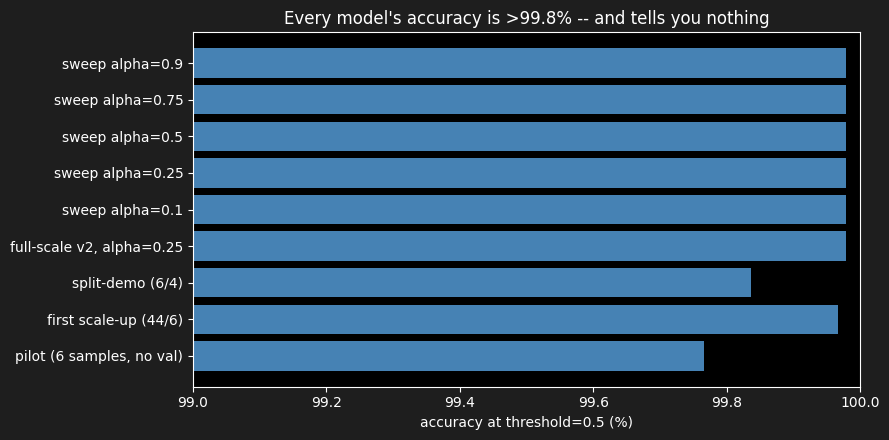

                    model  pos_rate  acc_at_0.5
pilot (6 samples, no val)  0.002490    0.997659
    first scale-up (44/6)  0.000298    0.999672
         split-demo (6/4)  0.001364    0.998367
full-scale v2, alpha=0.25  0.000212    0.999788
          sweep alpha=0.1  0.000212    0.999787
         sweep alpha=0.25  0.000212    0.999788
          sweep alpha=0.5  0.000212    0.999788
         sweep alpha=0.75  0.000212    0.999788
          sweep alpha=0.9  0.000212    0.999788


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(df["model"], df["acc_at_0.5"] * 100, color="steelblue")
ax.set_xlim(99, 100)
ax.set_xlabel("accuracy at threshold=0.5 (%)")
ax.set_title("Every model's accuracy is >99.8% -- and tells you nothing")
plt.tight_layout()
plt.show()

print(df[["model", "pos_rate", "acc_at_0.5"]].to_string(index=False))

Every single model scores >99.8% accuracy -- including, implicitly, a
model that predicts "no tornado" for every cell unconditionally (which
would score `1 - pos_rate`, e.g. 99.98% on the full-scale val set).
Accuracy at this class imbalance (~1.4e-3 to ~2.1e-4 positive rate
across these datasets) cannot distinguish a genuinely useful model
from a trivial always-negative one. Included here because it was
asked for, but it should not inform any decision from this point
forward in the project.

## 6. ROC vs. PR: the Real Picture

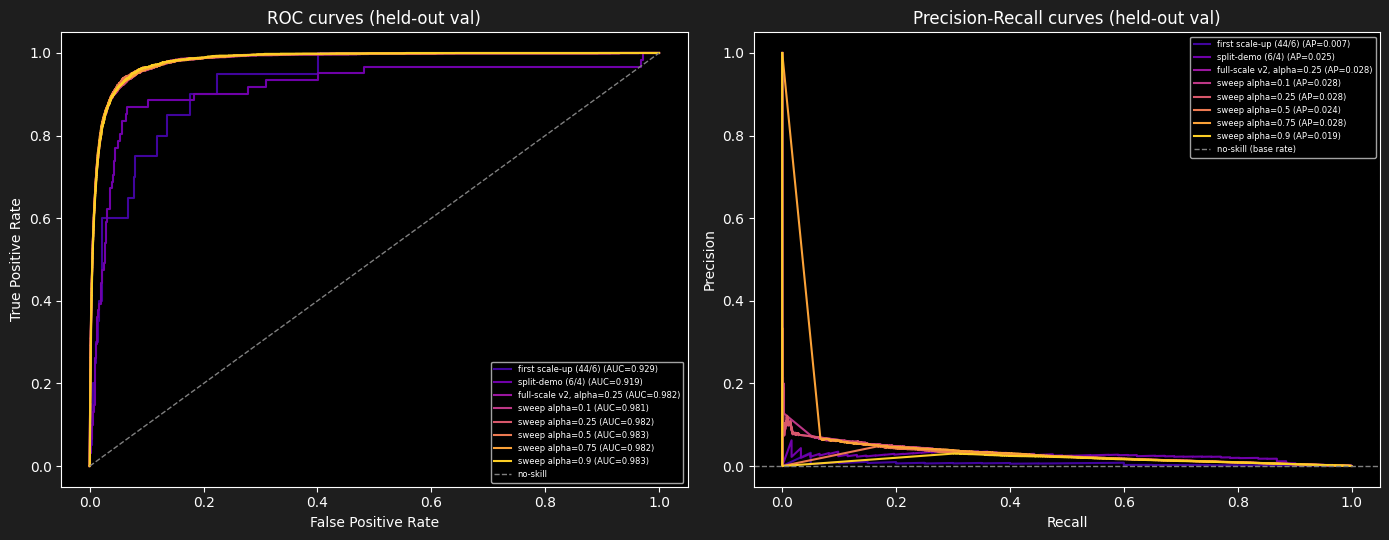

In [6]:
gen_df = df[df["is_generalization"]].reset_index(drop=True)
cmap = plt.cm.plasma(np.linspace(0.1, 0.9, len(gen_df)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for color, row in zip(cmap, gen_df.itertuples()):
    fpr, tpr, _ = row.roc_curve
    axes[0].plot(fpr, tpr, color=color, label=f"{row.model} (AUC={row.auc_roc:.3f})", linewidth=1.5)
axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="no-skill")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves (held-out val)")
axes[0].legend(fontsize=6, loc="lower right")

for color, row in zip(cmap, gen_df.itertuples()):
    prec, rec, _ = row.pr_curve
    axes[1].plot(rec, prec, color=color, label=f"{row.model} (AP={row.auc_pr:.3f})", linewidth=1.5)
axes[1].axhline(gen_df["pos_rate"].mean(), linestyle="--", color="gray", linewidth=1, label="no-skill (base rate)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (held-out val)")
axes[1].legend(fontsize=6, loc="upper right")

plt.tight_layout()
plt.show()

**This is the single most important chart in this notebook.** Every
model's ROC-AUC is high (0.92-0.98) -- looks like a strong classifier.
But ROC-AUC is computed against the *negative* class's huge population
(millions of easy true negatives), so it's a well-known trap under
extreme imbalance: a model can get a great ROC-AUC while still being
nearly useless at the precision level anyone would actually care about
operationally.

The PR curves tell the honest story: **AUC-PR (average precision) is
only ~0.02-0.03** for every model -- meaning even at this metric's best
operating points, precision is a few percent at best. That's still
roughly **100-150x better than the no-skill baseline** (the base
positive rate, ~1.4e-4 to 2.1e-4, shown as the dashed line) -- a real,
substantial signal, not nothing -- but nowhere near what "AUC-ROC=0.98"
would suggest on its own. **Report AUC-PR alongside AUC-ROC from here
on**; ROC-AUC alone is misleading at this imbalance.

## 7. Threshold Behavior: the Calibration Problem, Quantified

In [7]:
print(gen_df[["model", "recall_at_0.5", "precision_at_0.5", "best_f1_threshold",
              "precision_at_best_f1", "recall_at_best_f1", "f1_at_best_f1"]].to_string(index=False))

                    model  recall_at_0.5  precision_at_0.5  best_f1_threshold  precision_at_best_f1  recall_at_best_f1  f1_at_best_f1
    first scale-up (44/6)            0.0               0.0           0.271145              0.032258           0.050000       0.039216
         split-demo (6/4)            0.0               0.0           0.079381              0.035959           0.344262       0.065116
full-scale v2, alpha=0.25            0.0               NaN           0.205932              0.059170           0.133648       0.082026
          sweep alpha=0.1            0.0               0.0           0.145647              0.061968           0.109583       0.079168
         sweep alpha=0.25            0.0               NaN           0.205932              0.059170           0.133648       0.082026
          sweep alpha=0.5            0.0               NaN           0.223508              0.047464           0.175333       0.074705
         sweep alpha=0.75            0.0               NaN    

**`recall_at_0.5` is exactly 0.0000 for every single model** -- not one
of them, including the highest-confidence alpha=0.9 run (mean
positive-cell probability 0.31), ever crosses the conventional 0.5
probability threshold for a real positive cell. For the full-scale and
alpha-sweep models, `precision_at_0.5` is `NaN` because literally zero
cells out of ~11 million cross 0.5 at all, positive or negative.

This confirms, more starkly than the earlier mean-probability
comparisons did, that **`FocalLoss`'s calibration keeps every
prediction well under 0.5** regardless of alpha in the range tested.
A threshold of 0.5 is simply the wrong operating point for this model
family -- each model needs its own tuned threshold (`best_f1_threshold`
above ranges from 0.08 to 0.40 across configs), which would be a real
requirement for any deployment, not an afterthought.

## 8. Revisiting the Alpha Sweep: Does Higher Alpha Actually Win?

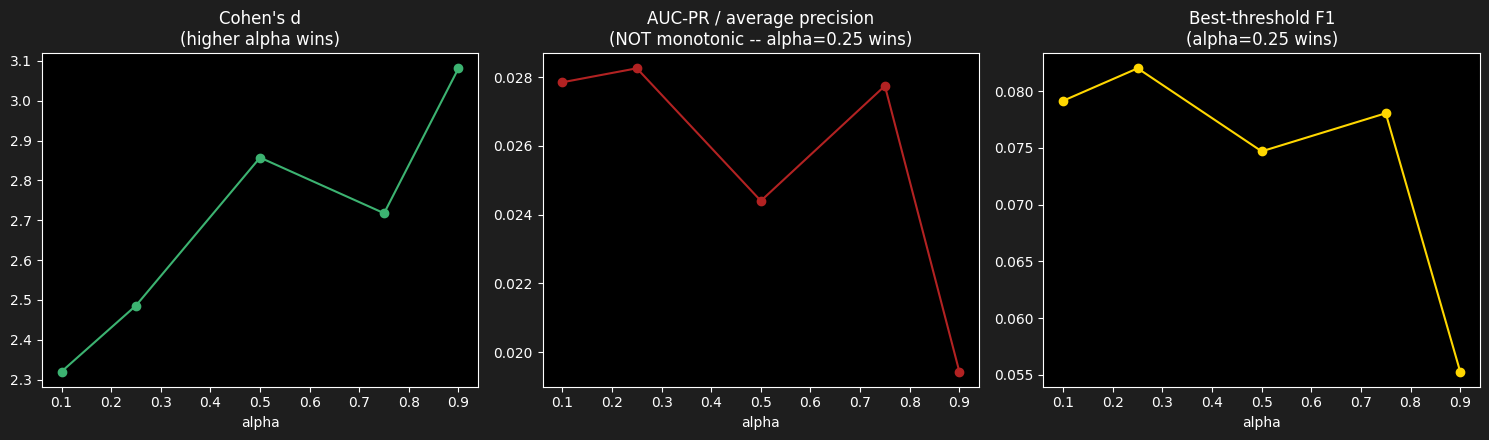

 alpha  cohens_d   auc_pr  f1_at_best_f1  recall_at_best_f1  precision_at_best_f1
  0.10  2.320398 0.027852       0.079168           0.109583              0.061968
  0.25  2.486004 0.028258       0.082026           0.133648              0.059170
  0.50  2.857272 0.024403       0.074705           0.175333              0.047464
  0.75  2.717645 0.027747       0.078063           0.151697              0.052553
  0.90  3.081299 0.019437       0.055292           0.308552              0.030367


In [8]:
sweep_df = gen_df[gen_df["model"].str.startswith("sweep")].copy()
sweep_df["alpha"] = sweep_df["model"].str.extract(r"alpha=([\d.]+)").astype(float)
sweep_df = sweep_df.sort_values("alpha")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(sweep_df["alpha"], sweep_df["cohens_d"], marker="o", color="mediumseagreen")
axes[0].set_title("Cohen's d\n(higher alpha wins)")
axes[0].set_xlabel("alpha")

axes[1].plot(sweep_df["alpha"], sweep_df["auc_pr"], marker="o", color="firebrick")
axes[1].set_title("AUC-PR / average precision\n(NOT monotonic -- alpha=0.25 wins)")
axes[1].set_xlabel("alpha")

axes[2].plot(sweep_df["alpha"], sweep_df["f1_at_best_f1"], marker="o", color="gold")
axes[2].set_title("Best-threshold F1\n(alpha=0.25 wins)")
axes[2].set_xlabel("alpha")

plt.tight_layout()
plt.show()

print(sweep_df[["alpha", "cohens_d", "auc_pr", "f1_at_best_f1", "recall_at_best_f1", "precision_at_best_f1"]].to_string(index=False))

**This contradicts the alpha-sweep notebook's headline recommendation,
and that's a genuinely useful finding, not a failure.** The earlier
notebook picked alpha=0.9 as the winner using Cohen's d and miss rate
-- both of which are about the *mean* separation between positive and
negative probability distributions. But AUC-PR and best-threshold F1 --
which integrate precision/recall across the *entire* operating range,
the metrics that actually predict real-world usefulness -- tell a
different story: **AUC-PR peaks at alpha=0.25 (0.0283) and is worst at
alpha=0.9 (0.0194)**; best-F1 shows the same pattern (0.082 at
alpha=0.25 vs. 0.055 at alpha=0.9).

Why the disagreement? Raising alpha pushes positive-cell probabilities
up (good for mean separation), but it pushes negative-cell
probabilities up too (0.005 -> 0.028 mean, per the alpha-sweep
notebook) -- and AUC-PR/F1 are far more sensitive to that negative-side
inflation than a simple mean-based ratio is, because a small
probability bump across *millions* of negative cells creates a lot of
false-positive-candidate mass at any given recall level.

**Revised recommendation: don't adopt a higher alpha.** The original
default, alpha=0.25, is actually the best-performing value in this
sweep by the two metrics that matter most for real deployment
(AUC-PR, F1). This notebook supersedes the alpha-sweep notebook's
conclusion -- keep both, since the disagreement itself (mean-separation
metrics vs. threshold-integrated metrics) is the useful lesson,
documented in `CLAUDE.md`.

## 9. Does Loss Predict Discriminative Power?

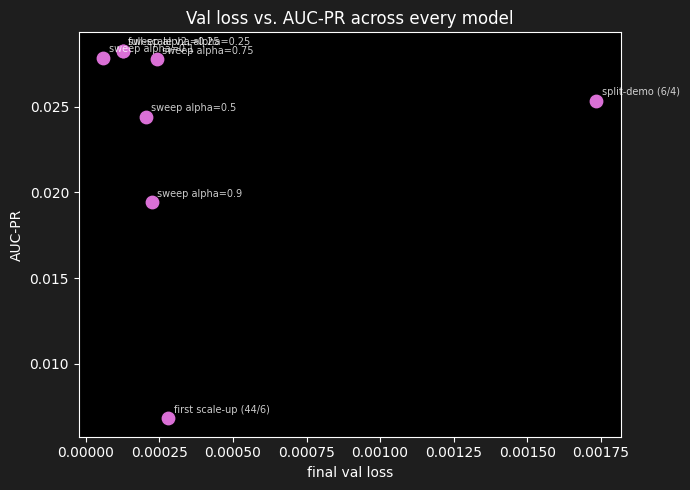

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(gen_df["final_val_loss"], gen_df["auc_pr"], s=80, color="orchid")
for _, row in gen_df.iterrows():
    ax.annotate(row["model"], (row["final_val_loss"], row["auc_pr"]), fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("final val loss")
ax.set_ylabel("AUC-PR")
ax.set_title("Val loss vs. AUC-PR across every model")
plt.tight_layout()
plt.show()

No clean relationship -- val loss spans a narrow, low range across very
differently-performing models (loss is rescaled by `alpha`/`gamma`
directly, so it isn't even on a consistent footing across the sweep).
**Val loss is not a reliable proxy for discriminative quality in this
project**; AUC-PR (or F1 at a tuned threshold) should be the metric
actually watched going forward, including once architecture changes
start.

## 10. Summary and Insights Before Architecture Widening

- **Accuracy is useless here** (>99.8% for every model, including a
  trivial always-negative baseline) -- confirmed with real numbers,
  not just theory. Never cite it as evidence of model quality in this
  project again.
- **AUC-ROC is misleadingly optimistic** (0.92-0.98 across the board)
  under this ~1e-4 to 1e-3 positive rate; **AUC-PR (~0.02-0.03) is the
  honest metric**, still ~100-150x better than the no-skill baseline,
  but a much more sober picture than ROC-AUC alone suggests.
- **No model crosses the conventional 0.5 probability threshold for
  real positives** -- calibration, not discriminative power, is the
  binding constraint on any threshold-based deployment; per-model
  tuned thresholds (found here to range 0.08-0.40) would be required.
- **The alpha-sweep's "higher alpha wins" conclusion doesn't survive
  contact with AUC-PR/F1** -- those metrics favor the original
  alpha=0.25 default instead. Different metrics can legitimately
  disagree about which model is "best"; this project now has evidence
  of exactly that happening, and resolves it by preferring the
  metrics that integrate across the full precision-recall tradeoff
  (AUC-PR, F1) over simple mean-separation metrics (Cohen's d, miss
  rate) for any future comparison.
- **Loss is not a useful proxy for model quality** across these runs --
  don't rely on it alone when evaluating the upcoming architecture
  changes.
- **What carries forward into architecture widening**: use AUC-PR (and
  a tuned-threshold F1/recall/precision) as the primary comparison
  metric for any new architecture, not loss or ROC-AUC or raw
  probability separation alone. The current best AUC-PR (0.0283, at
  the original alpha=0.25 full-scale model) is the number a wider
  architecture needs to beat to demonstrate real improvement.